# COGS 108 - EDA Checkpoint

## Authors

- Saemi Namgung: Conceptualization, Analysis, Project administration, Writing – original draft,Writing – review & editing
- Evelyn Na: Software, Data curation, Visualization, Methodology, Writing – review & editing
- Jookyoung Lee: Conceptualization, Analysis, Project administration, Software, Writing - review & editing
- Agam Chahal: Background research, Prior Research Analysis, Software
- Alex Sun: Background research, Analysis, Proofreading


# Research Question

Sleep deprivation is increasingly common among university students, potentially undermining the cognitive processes required for academic success. Therefore, we ask: Does average nightly sleep duration ($TotalSleepTime$) significantly predict end-of-semester GPA ($term\_gpa$) for first-year college students when controlling for prior academic performance ($cum\_gpa$) and demographic factors?



## Background and Prior Work

Sleep plays an essential role in cognition, memory, and learning. Research in neuroscience shows that sleep is an active process during which the brain consolidates newly learned information and strengthens memory. These processes are important for attention, executive function, and long-term learning, all of which are necessary for academic success. When sleep is inadequate or disrupted, these cognitive functions can be impaired, making it more difficult for students to perform well academically (<a href="https://www.nature.com/articles/nrn2762" target="_blank">Diekelmann & Born, 2010</a>).

Several empirical studies have examined the relationship between sleep patterns and academic performance in student populations. An in-depth study of medical students found that ongoing sleep deprivation over a three-month period was associated with declines in academic scores, suggesting that reduced sleep may negatively affect academic outcomes (<a href="https://www.cureus.com/articles/380070-impact-of-sleep-deprivation-on-cognition-and-academic-scores-a-three-month-longitudinal-study-among-indian-medical-students" target="_blank">Impact of Sleep Deprivation on Cognition and Academic Scores, Cureus</a>). In addition, research by Gaultney (2017) found that among college students, sleep duration and sleep timing were associated with academic performance measures such as GPA (<a href="https://www.tandfonline.com/doi/full/10.1080/10963758.2017.1297713" target="_blank">Gaultney, 2017</a>). Together, these studies provide evidence that sleep behavior is meaningfully related to academic outcomes, though they differ in how thoroughly they control for other influencing factors. Although the relationship between sleep and academic performance has been studied before, this project does not aim to introduce a new theoretical idea. Instead, it focuses on confirming and extending existing findings using a data science approach and publicly available datasets. Many previous studies do not fully account for prior academic performance, which makes it harder to separate the effect of sleep from a student’s existing ability. By controlling for prior GPA and demographic factors, our analysis examines whether sleep duration remains a meaningful predictor of end-of-semester GPA.

To better understand the specific contribution of sleep to academic success, researchers recommend controlling for prior academic performance and relevant demographic variables. Prior GPA is a strong predictor of future academic outcomes and should be included in analytical models to avoid attributing existing differences in ability to sleep alone. By using regression models that incorporate prior performance and demographic controls, it becomes possible to evaluate whether sleep duration remains a significant predictor of end-of-semester GPA. This project follows that approach by examining the relationship between average nightly sleep duration and semester GPA while accounting for baseline academic performance and demographic factors.


# Hypothesis


We hypothesize that average nightly sleep duration ($TotalSleepTime$) will be a positive and significant predictor of end-of-semester GPA ($term\_gpa$), such that an increase in sleep duration is associated with higher academic achievement even when controlling for prior performance ($cum\_gpa$) and demographic factors. This expectation is grounded in the established neurobiological role of sleep in memory consolidation, executive function, and emotional regulation, all of which are critical for the high-level cognitive processing required to succeed in a college environment. By accounting for baseline academic ability and course load, we aim to isolate the specific impact that sleep hygiene has on a student's ability to maintain and improve their grades.

## Data

### Data overview

 For each dataset include the following information
- Dataset #1
  - Dataset Name: Nightly sleep time and GPA in first-years
  - Link to the dataset: https://cmustatistics.github.io/data-repository/psychology/cmu-sleep.html 
  - Number of observations: There were a total of 634 participants in this study, who each received a Fitbit to track their sleep and physical activity.
  - Number of variables: 15
  - Description of the variables most relevant to this project
    - TotalSleepTime (Primary Predictor): Average nightly sleep duration in minutes, calculated from the main sleep episode.
    - term_gpa (Outcome): End-of-term GPA for the semester being studied, used as the measure of academic performance.
    - cum_gpa (Control): Prior cumulative GPA, used to account for baseline academic ability.
    - Zterm_units_ZofZ (Control): Standardized course load relative to the student's cohort.
    - demo_gender, demo_race, demo_firstgen (Controls): Demographic identifiers used to account for institutional and systemic factors.
    - frac_nights_with_data (Data Quality): Used to filter subjects with insufficient or unreliable sleep tracking data.
  - Descriptions of any shortcomings this dataset has with respect to the project:
    - Selection Bias: The data only includes students who opted into wearing a Fitbit, which may exclude specific demographics or those with extremely irregular schedules.
    - Generalizability: The participants are from three specific, high-ranking universities, meaning the results may not generalize to students at community colleges or different institutional types.
    - Measurement Error: Fitbit data, while objective, can occasionally misclassify periods of quiet rest as sleep or fail due to battery depletion, which could introduce noise into the TotalSleepTime variable.



In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [ ]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Sleep Patterns and Academic Performance

This dataset examines the relationship between nightly sleep duration and academic performance among first-year college students. The primary predictor variable is TotalSleepTime, which represents the average nightly sleep duration in minutes, calculated from the student’s main sleep episode as tracked by a Fitbit device. For interpretation, 420–540 minutes (7–9 hours) per night is generally considered a healthy range for young adults. Values significantly below 360 minutes (6 hours) may indicate chronic sleep deprivation, while extremely high values could suggest irregular sleep patterns or measurement anomalies. The primary outcome variable is term_gpa, which measures end-of-term GPA for the semester being studied. GPA is typically measured on a 0.0–4.0 scale, where higher values represent stronger academic performance. In this context, term GPA serves as an objective measure of academic success during the same semester in which sleep was measured. The dataset also includes important control variables. cum_gpa (cumulative GPA prior to the term) accounts for baseline academic ability and prior performance. Zterm_units_ZofZ represents standardized course load relative to the student’s cohort, controlling for differences in academic workload. Demographic controls such as demo_gender, demo_race, and demo_firstgen help account for structural and institutional factors that may influence academic outcomes. Finally, frac_nights_with_data measures the fraction of nights with valid sleep data, serving as a data quality indicator to ensure that sleep estimates are reliable. Together, these variables allow for analysis of whether sleep duration is associated with academic performance while controlling for prior achievement, workload, and demographic factors
One major concern is selection bias. The dataset includes students who opted into wearing a Fitbit device for sleep tracking. Students willing to participate in such a study may differ systematically from those who did not, potentially being more health-conscious, organized, or academically motivated. As a result, the sample may not fully represent the broader student population. Another limitation relates to generalizability. The participants come from a limited number of selective universities. Therefore, findings may not extend to students at community colleges, non-selective institutions, or students in different age groups. Measurement error is also possible. While Fitbit data provides objective tracking, wearable devices can misclassify quiet wakefulness as sleep or fail to record data due to battery depletion or device removal. This may introduce noise into the TotalSleepTime variable. Finally, the dataset is observational rather than experimental. Even if a statistical relationship between sleep and GPA is found, it does not establish causation. Unobserved variables - such as stress levels, time management skills, or mental health - may influence both sleep and academic performance.


In [ ]:

# TotalSleepTime → term_gpa (controlling for cum_gpa + demographics)


import pandas as pd
import numpy as np
import os
from IPython.display import display


#print(os.getcwd())
#!ls data/00-raw


# Load raw dataset



df_raw = pd.read_csv("data/00-raw/cmu-sleep.csv")

print("Initial shape:", df_raw.shape)


# Check missing values for key variables

key_columns = [
    'term_gpa',
    'cum_gpa',
    'TotalSleepTime',
    'term_units',
    'Zterm_units_ZofZ',
    'demo_race',
    'demo_gender',
    'demo_firstgen'
]

print("\nMissing values per column:")
print(df_raw[key_columns].isna().sum())

# Drop rows missing key variables

df_clean = df_raw.dropna(subset=[
    'term_gpa',
    'cum_gpa',
    'TotalSleepTime'
]).copy()


numeric_cols = [
    'term_gpa',
    'cum_gpa',
    'TotalSleepTime',
    'term_units',
    'Zterm_units_ZofZ'
]

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


# Remove impossible GPA values

df_clean = df_clean[
    (df_clean['term_gpa'] >= 0) & (df_clean['term_gpa'] <= 4)
]

df_clean = df_clean[
    (df_clean['cum_gpa'] >= 0) & (df_clean['cum_gpa'] <= 4)
]

# ------------------------------------------
# Remove unrealistic sleep values. Unsure if we should keep/leave yet. Miniscule amounts of sleep aren't uncommon in college.
# ------------------------------------------
# df_clean = df_clean[
#     (df_clean['TotalSleepTime'] >= 120) & 
#     (df_clean['TotalSleepTime'] <= 900)
# ]


# Remove duplicates

df_clean = df_clean.drop_duplicates()


# Final Dataset Summary

print("\nFinal shape after cleaning:", df_clean.shape)
print("\nSummary statistics:")
print(df_clean.describe())

# ------------------------------------------
# Save cleaned dataset to 01-interim
# ------------------------------------------
df_clean.to_csv("data/01-interim/cmu_sleep_interim.csv", index=False)

print("\nInterim dataset saved to data/01-interim/cmu_sleep_interim.csv")
print("\nData cleaning complete.")


print("___________________________________________________")
shape_tbl = pd.DataFrame({
    "Dataset": ["Raw", "Cleaned"],
    "Rows": [df_raw.shape[0], df_clean.shape[0]],
    "Cols": [df_raw.shape[1], df_clean.shape[1]],
})

display(
    shape_tbl.style
    .hide(axis="index")
    .set_caption("Dataset shapes (before vs after cleaning)")
)

# Missingness (count + %)
miss = pd.DataFrame({
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().mean() * 100)
}).sort_values("missing_count", ascending=False)

miss_show = miss[miss["missing_count"] > 0].copy()
if miss_show.empty:
    miss_show = pd.DataFrame({"missing_count": [0], "missing_pct": [0.0]}, index=["(no missing values)"])

display(
    miss_show.style
    .format({"missing_count": "{:,.0f}", "missing_pct": "{:.2f}%"})
    .bar(subset=["missing_pct"])
    .set_caption("Missing values by column")
)

# Summary stats
# Show numeric columns only, rounded
desc = df_clean.describe(include=[np.number]).T
desc = desc.rename(columns={
    "count": "n", "mean": "mean", "std": "std", "min": "min",
    "25%": "p25", "50%": "median", "75%": "p75", "max": "max"
})

display(
    desc.style
    .format("{:,.3f}")
    .set_caption("Summary statistics (numeric columns)")
)

# Units coverage
units_cols = [c for c in ["term_units", "Zterm_units_ZofZ"] if c in df_clean.columns]
if units_cols:
    units_cov = pd.DataFrame({
        "column": units_cols,
        "non_null_count": [df_clean[c].notna().sum() for c in units_cols],
        "non_null_pct": [df_clean[c].notna().mean() * 100 for c in units_cols],
    })
    display(
        units_cov.style
        .hide(axis="index")
        .format({"non_null_count": "{:,.0f}", "non_null_pct": "{:.2f}%"})
        .set_caption("Course load columns coverage (units)")
    )
else:
    print("term_units / Zterm_units_ZofZ not found in df columns.")



Initial shape: (634, 15)

Missing values per column:
term_gpa            0
cum_gpa             0
TotalSleepTime      0
term_units          0
Zterm_units_ZofZ    0
demo_race           0
demo_gender         0
demo_firstgen       0
dtype: int64

Final shape after cleaning: (634, 15)

Summary statistics:
         subject_id       study  bedtime_mssd  TotalSleepTime  midpoint_sleep  \
count    634.000000  634.000000    634.000000      634.000000      634.000000   
mean   13005.892744    3.181388      0.451688      397.323874      398.679186   
std    26496.593477    1.317125      1.393632       50.856725       72.710945   
min        1.000000    1.000000      0.004505      194.782609      247.071429   
25%      178.000000    2.000000      0.074694      366.930077      345.182692   
50%      358.500000    3.000000      0.135007      400.395833      388.245726   
75%      592.750000    4.000000      0.291698      430.114583      437.655263   
max    99978.000000    5.000000     20.849225     

Dataset,Rows,Cols
Raw,634,15
Cleaned,634,15


,missing_count,missing_pct
term_units,147,23.19%
Zterm_units_ZofZ,147,23.19%


,n,mean,std,min,p25,median,p75,max
subject_id,634.000,"13,005.893","26,496.593",1.000,178.000,358.500,592.750,"99,978.000"
study,634.000,3.181,1.317,1.000,2.000,3.000,4.000,5.000
bedtime_mssd,634.000,0.452,1.394,0.005,0.075,0.135,0.292,20.849
TotalSleepTime,634.000,397.324,50.857,194.783,366.930,400.396,430.115,587.667
midpoint_sleep,634.000,398.679,72.711,247.071,345.183,388.246,437.655,724.667
frac_nights_with_data,634.000,0.867,0.179,0.214,0.821,0.932,1.000,1.000
daytime_sleep,634.000,41.164,27.389,2.269,23.098,34.982,51.249,292.304
cum_gpa,634.000,3.466,0.438,1.210,3.232,3.558,3.790,4.000
term_gpa,634.000,3.450,0.500,0.350,3.233,3.556,3.810,4.000
term_units,487.000,29.392,17.643,5.000,15.000,17.000,48.000,73.000


column,non_null_count,non_null_pct
term_units,487,76.81%
Zterm_units_ZofZ,487,76.81%


## Results

### Overview on Sleep TIme and Performance

To better understand the relationship between sleep behavior and academic performance, we conducted several exploratory analyses using the cleaned dataset. We first examined the distribution of total sleep time among students. The histogram shows that most students sleep between approximately 350 and 450 minutes per night (about 5.8–7.5 hours), with the distribution centered around roughly 400 minutes (6.7 hours). This indicates that while sleep duration varies across students, the majority of observations cluster within a relatively narrow range.

Next, we explored how sleep duration varies across different academic performance groups. Students were grouped into GPA categories (Low, Medium, High, and Very High), and sleep duration was compared across these groups using a boxplot. The results suggest a modest trend in which students with higher GPAs tend to have slightly higher median sleep durations. However, there is still considerable overlap between the groups, indicating that sleep duration alone does not strongly determine academic performance.

We also investigated the relationship between sleep schedule regularity and GPA using the bedtime variability metric (bedtime_mssd). The scatterplot suggests a slight negative relationship between sleep irregularity and academic performance, meaning that students with more irregular sleep schedules tend to have slightly lower GPAs on average. This pattern is further supported by the grouped boxplot, where students with more consistent sleep schedules generally show slightly higher median GPAs compared to those with irregular sleep patterns.

Overall, these exploratory analyses suggest that while both sleep duration and sleep consistency show some association with academic performance, the relationships appear relatively modest. Academic performance likely depends on multiple factors beyond sleep behavior, but the results indicate that maintaining adequate and consistent sleep may still contribute positively to student outcomes.



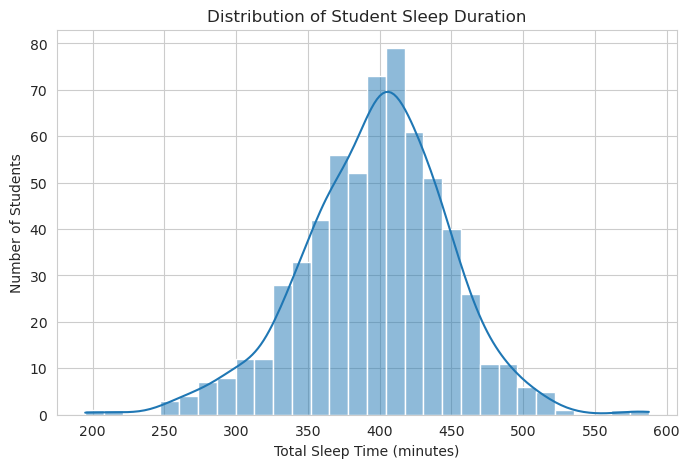

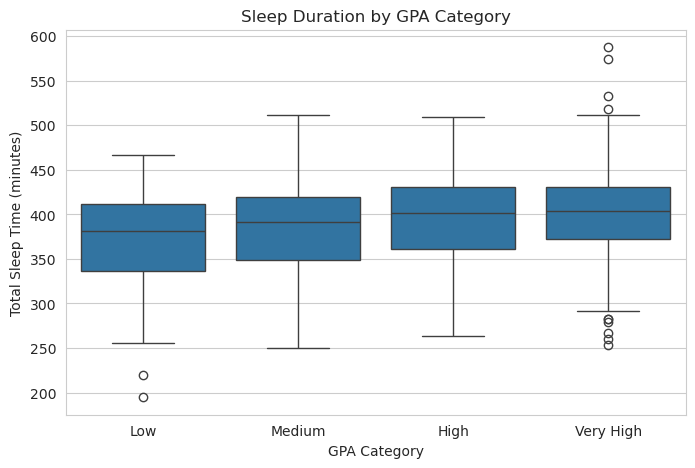

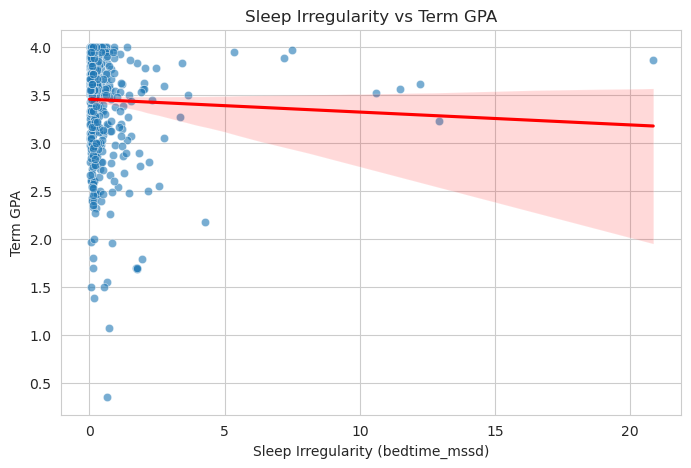

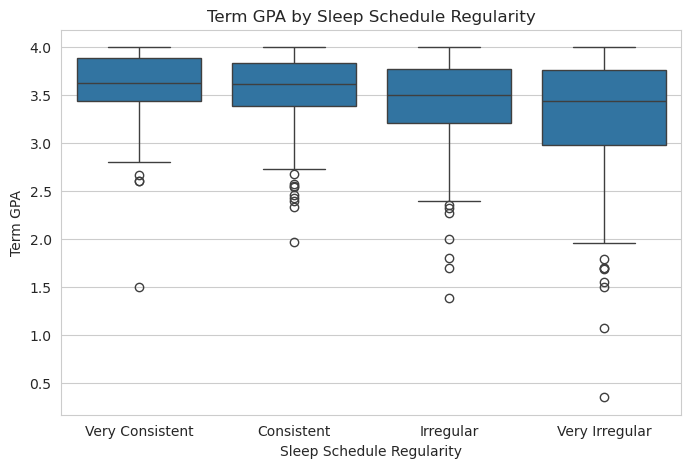

In [ ]:
df = pd.read_csv("data/02-processed/cmu_sleep_processed.csv")
sns.set_style("whitegrid")

#-------- Sleep distribution---------------
plt.figure(figsize=(8,5))

sns.histplot(df_clean["TotalSleepTime"], bins=30, kde=True)

plt.title("Distribution of Student Sleep Duration")
plt.xlabel("Total Sleep Time (minutes)")
plt.ylabel("Number of Students")

plt.show()

#------------------------------
#-----------Compare GPA with sleep duration 
df_clean["gpa_category"] = pd.cut(
    df_clean["term_gpa"],
    bins=[0,2.5,3.0,3.5,4.0],
    labels=["Low","Medium","High","Very High"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="gpa_category",
    y="TotalSleepTime"
)

plt.title("Sleep Duration by GPA Category")
plt.xlabel("GPA Category")
plt.ylabel("Total Sleep Time (minutes)")

plt.show()

#---------------------------------------------

df_plot = df_clean.copy()


df_plot["irregularity_bin"] = pd.qcut(df_plot["bedtime_mssd"], 8)


binned = df_plot.groupby("irregularity_bin", observed = False)["term_gpa"].mean().reset_index()


binned["mid"] = df_plot.groupby("irregularity_bin", observed = False)["bedtime_mssd"].mean().values

plt.figure(figsize=(8,5))

plt.plot(binned["mid"], binned["term_gpa"], marker="o")

plt.title("Average GPA vs Sleep Irregularity (Binned)")
plt.xlabel("Sleep Irregularity (bedtime_mssd)")
plt.ylabel("Average Term GPA")

plt.grid(True)
plt.show()

#--------------------------------------------
df_clean["sleep_irregularity_group"] = pd.qcut(
    df_clean["bedtime_mssd"],
    4,
    labels=["Very Consistent","Consistent","Irregular","Very Irregular"]
)


plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="sleep_irregularity_group",
    y="term_gpa"
)

plt.title("Term GPA by Sleep Schedule Regularity")
plt.xlabel("Sleep Schedule Regularity")
plt.ylabel("Term GPA")

plt.show()

#### Sleep Duration and Academic Performance Across Demographic Groups
The regression analysis shows a weak positive relationship between total sleep time and term GPA, suggesting that students who sleep longer tend to have slightly higher academic performance on average. The correlation matrix supports this observation, showing a modest correlation between sleep duration and term GPA (r ≈ 0.20), while the strongest relationship appears between term GPA and cumulative GPA (r ≈ 0.64). When examining the relationship across demographic groups, the overall trend remains consistent, indicating that the association between sleep duration and GPA appears similar across gender, race, and first-generation status groups.

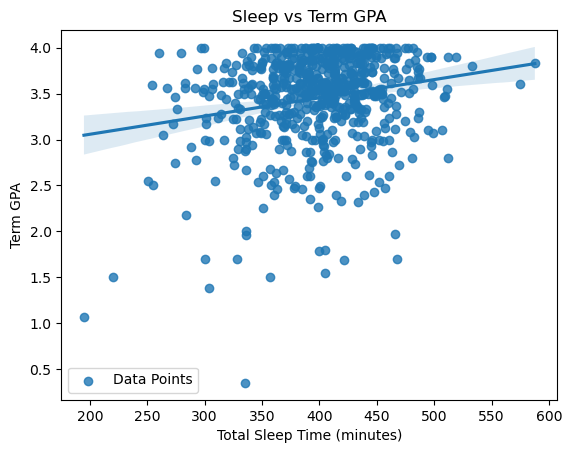

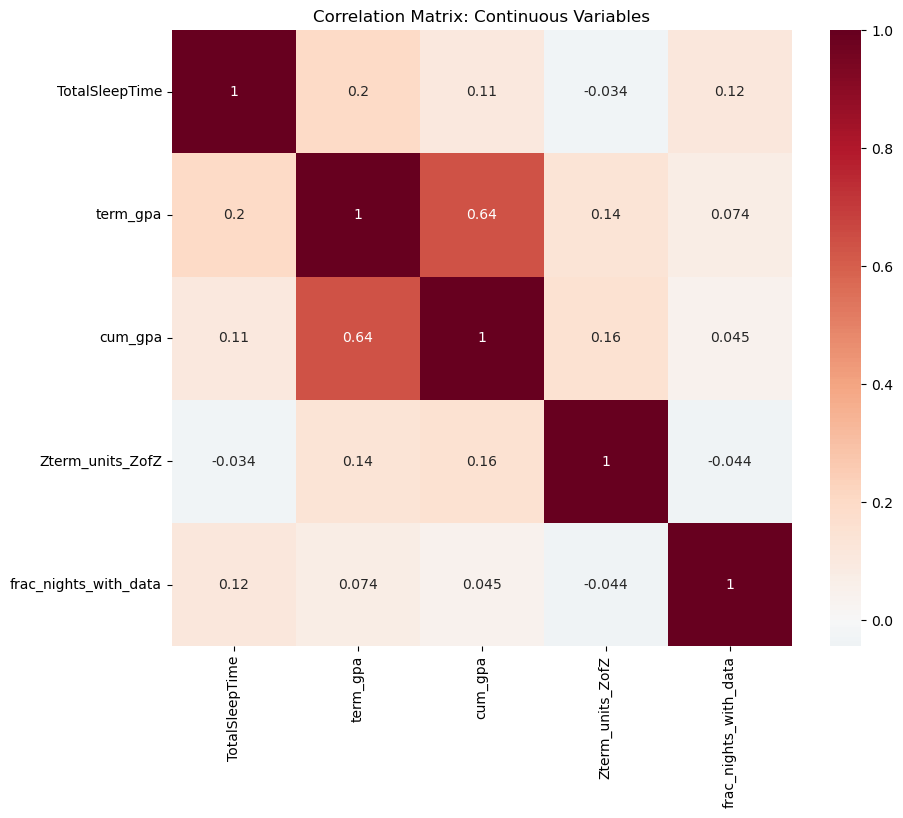

Correlation with Term GPA:
term_gpa                 1.000000
cum_gpa                  0.638035
TotalSleepTime           0.201677
Zterm_units_ZofZ         0.140686
frac_nights_with_data    0.074121
Name: term_gpa, dtype: float64


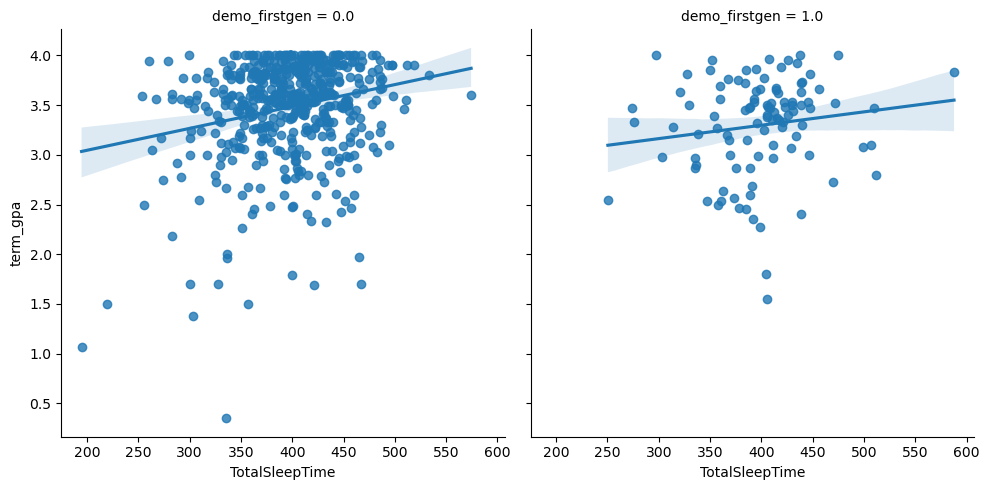

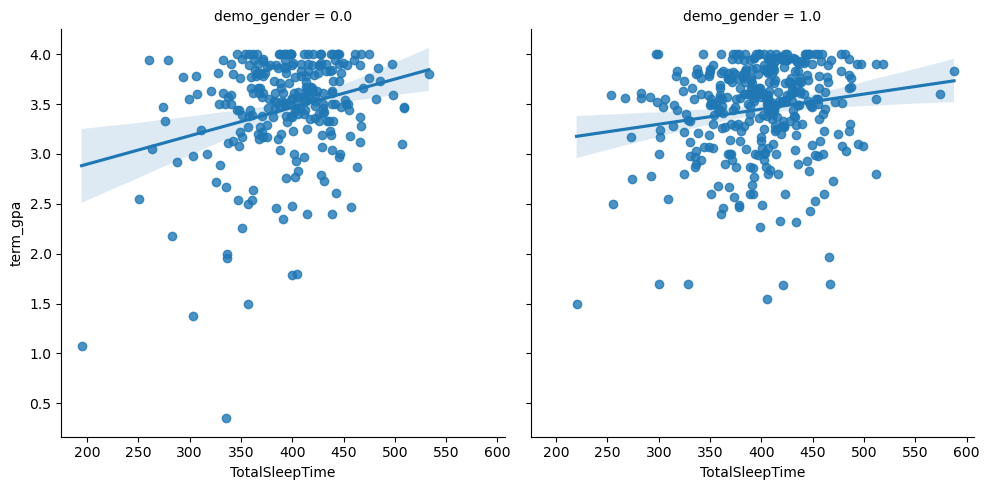

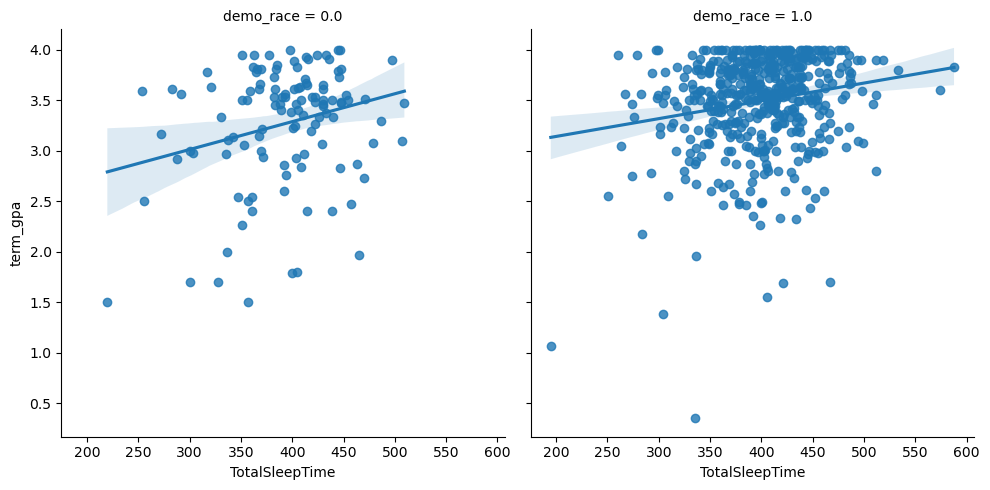

In [ ]:
import matplotlib.pyplot as plt

vars_of_interest = [
    'TotalSleepTime', 'term_gpa', 'cum_gpa', 
    'Zterm_units_ZofZ', 'demo_gender', 'demo_race', 
    'demo_firstgen', 'frac_nights_with_data'
]


continuous_vars = [
    'TotalSleepTime', 
    'term_gpa', 
    'cum_gpa', 
    'Zterm_units_ZofZ', 
    'frac_nights_with_data'
]

# 1. Regression Plot
sns.regplot(data=df, x='TotalSleepTime', y='term_gpa', label='Data Points')
plt.title('Sleep vs Term GPA')
plt.xlabel('Total Sleep Time (minutes)')
plt.ylabel('Term GPA')
plt.legend()
plt.show()


# 2. Correlation Matrix (Filtered for continuous variables)
plt.figure(figsize=(10, 8))
# Only correlate the continuous columns
corr_matrix = df[continuous_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix: Continuous Variables')
plt.show()

# --- 3. QUICK STATS SUMMARY ---
print("Correlation with Term GPA:")
print(corr_matrix['term_gpa'].sort_values(ascending=False))


# need to get clean demo_ data
df_clean = df.copy()
demo_cols = ['demo_firstgen', 'demo_gender', 'demo_race']
for col in demo_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')    
    df_clean = df_clean[df_clean[col].isin([0, 1])]


# Control for First-Gen status visually
sns.lmplot(data=df_clean, x='TotalSleepTime', y='term_gpa', col='demo_firstgen')
sns.lmplot(data=df_clean, x='TotalSleepTime', y='term_gpa', col='demo_gender')
sns.lmplot(data=df_clean, x='TotalSleepTime', y='term_gpa', col='demo_race')

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?
> This study involves human subjects and includes sensitive academic and behavioral data such as sleep duration, GPA, and demographic characteristics. Direct student data collection will require informed consent, which includes a detailed explanation of the study's objectives, the data's purpose, and the fact that participation is entirely voluntary. Participants will be told that participation or non-participation will not have an impact on their academic status.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
> Self-reported sleep data may add social desirability bias or recollection bias. Also, there may be systematic differences between students who decide to participate and who do not (e.g., more academically engaged kids). The results will be cautiously interpreted, and these limitations will be noted.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
> Personally identifiable information will not be collected or retained. Only the variables necessary for the research question will be included, and all data will be anonymized before analysis.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
> Rather than drawing inferences regarding group differences, demographic characteristics are included in order to adjust for confounding effects. Their inclusion helps prevent erroneous findings caused by omitted variable bias and permits investigation of whether observed connections differ between groups.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
> Data will be stored on secure, access-restricted systems used for academic research. Only authorized members of the research team will have access to the dataset.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
> If data are collected directly from participants, individuals will be informed that they may request removal of their data prior to anonymization and analysis.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
> Data will be retained only for the duration of the course project and deleted afterward in accordance with course and institutional guidelines.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
> This analysis acknowledges that sleep duration is only one of many factors influencing academic performance. Limitations are examined in relation to broader contextual variables like workload, financial stress, mental health, and institutional assistance.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
> Prior academic performance (cumulative GPA) is included as a control variable to reduce confounding. Remaining limitations due to unobserved variables will be explicitly acknowledged.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
> Results will be presented transparently, emphasizing effect sizes and uncertainty rather than overstating significance.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
> No personally identifiable information will be used or displayed in analysis outputs.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
> The analysis workflow will be documented and reproducible, allowing results to be reviewed or re-run if concerns arise.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
> Instead of generating predictions or making decisions, the model makes use of demographic characteristics, sleep duration, and past GPA for statistical adjustment. Individual-level evaluations are made without the use of variables.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
> This study is not primarily concerned with group-level differences. To make sure results are not false, interaction effects and subgroup trends could be investigated descriptively.

 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
> The coefficients of the regression model can be interpreted in terms of correlations between GPA and sleep duration.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?
> Limitations such as correlational design, potential measurement error, and omitted variables will be clearly stated.

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
> This research is not meant to be used in situations when decisions must be made. However, there is a risk that results could be misused to blame students or enforce rigid behavioral expectations. Findings will be presented as informative rather than prescriptive, with a focus on wellness-oriented and helpful interpretations, in order to reduce this.


## Team Expectations 


- **Communication:**
  Our team will communicate primarily through **messaging** for updates and questions, and **Zoom** for meetings. Team members are expected to check messages regularly and respond within 12 hours on weekdays and 24 hours on weekends. We will hold **weekly/bi-weekly Zoom meetings** to discuss progress, assign tasks, and address questions or concerns.

- **Respectful Collaboration:**
  We agree to communicate respectfully and constructively, especially when giving feedback or disagreeing. We assume all feedback is well-intentioned and aimed at improving the project.

- **Equal Contribution and Accountability:**
  All team members are expected to contribute equally in effort across the project. While roles may differ based on strengths (e.g., coding, writing, analysis), everyone will participate in coding, writing, and editing at some point. Team members will complete assigned tasks by agreed-upon deadlines and communicate early if they are struggling.

- **Decision Making:**
  Most decisions will be made through group discussion and consensus or majority agreement. For time-sensitive decisions, the team member responsible for that section may make the decision and update the group afterward.

- **Handling Conflict and Challenges:**
  If conflicts arise, we will address them openly and respectfully as a group. If a team member is unable to meet expectations, they are expected to notify the group as soon as possible so responsibilities can be adjusted. If issues persist, we will follow the course guidelines for addressing problem teammates.

By contributing to this project and adding our names to the submission, we confirm that we have read the COGS108 Team Policies, agree to these expectations, and intend to fulfill them throughout the quarter.

## Project Timeline Proposal



| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/4  |  1 PM | Each member worked on assigned sections of the project proposal (research question, data, ethics, team expectations, timeline)  | Discuss and finalize research question; review proposal sections; allocate responsibilities to each team member | 
| 2/11  |  7 PM |  Identify and explore dataset; conduct preliminary data inspection; review background literature | Discuss dataset suitability and ethics; finalize variables; confirm overall analysis plan | 
| 2/18  | 7 PM  | Complete data wrangling and exploratory data analysis (EDA); draft initial visualizations  | Review and edit wrangling/EDA; discuss patterns and potential issues; refine analysis and visualization approach   |
| 3/4  | 7 PM  | Conduct main statistical analysis; update visualizations; draft results section | Discuss analysis results; interpret findings; plan discussion and conclusion sections   |
| 3/11  | 7 PM  | Draft full project (results, discussion, conclusion); integrate feedback | Review full project draft; finalize writing, figures, and interpretations |
| 3/18  | Before 11:59 PM  | Final edits and checks completed | Submit Final Project and complete Group Project Surveys |